# 📊 Customer Segmentation & RFM Analytics

## 🎯 Executive Overview & Business Objectives
Customer segmentation is a foundational analytical technique that enables businesses to group customers based on shared behavioral traits, purchasing patterns, and monetary value. 

In this project, we implement the **RFM (Recency, Frequency, Monetary)** framework to analyze transaction history and customer demographic profiles. By decomposing customer behavior into three quantifiable dimensions:
- **Recency ($R$)**: How recently did the customer make a purchase?
- **Frequency ($F$)**: How often does the customer make purchases?
- **Monetary ($M$)**: How much total revenue does the customer generate?

We assign customers into actionable behavioral segments (such as *Champions*, *Loyal Customers*, *Potential Loyalists*, *At Risk*, and *Lost Customers*) to enable hyper-targeted marketing campaigns, improve customer retention, and maximize Customer Lifetime Value (CLV).

---

## 1. 📦 Environment Setup & Library Imports
We import core scientific and visualization libraries: `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib` / `seaborn` for exploratory and statistical visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure environment settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print("Environment successfully initialized.")

Environment successfully initialized.


## 2. 📂 Data Ingestion
We load the raw transactional records (`Customer_Transactions.csv`) and customer profile master data (`Customer_Master_Data.xlsx`).

In [2]:
# Load datasets
transactions = pd.read_csv('Customer_Transactions.csv')
customers = pd.read_excel('Customer_Master_Data.xlsx')

print(f"Transactions Dataset: {transactions.shape[0]:,} rows | {transactions.shape[1]} columns")
print(f"Customer Master Dataset: {customers.shape[0]:,} rows | {customers.shape[1]} columns")

Transactions Dataset: 23,050 rows | 3 columns
Customer Master Dataset: 1,000 rows | 9 columns


## 3. 🔍 Exploratory Data Inspection & Data Quality Profiling
We inspect column schemas, data types, sample records, and check for missing or anomalous values across both datasets.

In [3]:
print("--- Transactions Sample ---")
display(transactions.head())

print("\n--- Customer Master Sample ---")
display(customers.head())

--- Transactions Sample ---

--- Customer Master Sample ---


,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [4]:
# Missing value audit
trans_summary = pd.DataFrame({
    'Data Type': transactions.dtypes,
    'Missing Count': transactions.isna().sum(),
    'Null %': (transactions.isna().mean() * 100).round(2)
})
print("Transactions Data Quality:")
display(trans_summary)

cust_summary = pd.DataFrame({
    'Data Type': customers.dtypes,
    'Missing Count': customers.isna().sum(),
    'Null %': (customers.isna().mean() * 100).round(2)
})
print("\nCustomers Data Quality:")
display(cust_summary)

Transactions Data Quality:

Customers Data Quality:


,Data Type,Missing Count,Null %
CustomerID,object,0,0.00
TransactionDate,object,0,0.00
TransactionAmount,float64,0,0.00


,Data Type,Missing Count,Null %
CustomerID,object,0,0.00
Name,object,0,0.00
Email,object,0,0.00
Gender,object,0,0.00
Age,int64,0,0.00
City,object,0,0.00
MaritalStatus,object,0,0.00
NumChildren,int64,0,0.00
JoinDate,datetime64[ns],0,0.00


## 4. 🧹 Data Cleaning, Parsing & Relational Merging
We convert date columns into proper `datetime64` types and merge transactional data with customer master records on `CustomerID`.

In [5]:
# Parse dates with explicit handling
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'], format='mixed')
customers['JoinDate'] = pd.to_datetime(customers['JoinDate'], format='mixed')

# Relational merge on CustomerID
merged_df = transactions.merge(customers, on='CustomerID', how='inner')

print(f"Cleaned & Merged Records: {len(merged_df):,} transactions across {merged_df['CustomerID'].nunique():,} unique customers")
display(merged_df.head(3))

Cleaned & Merged Records: 23,050 transactions across 1,000 unique customers


,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03


## 5. 🧮 RFM Metric Computation
We calculate the foundational RFM metrics at the individual customer level:
1. **Recency ($R$)**: Days elapsed from the customer's most recent transaction to the global analysis reference date (`max(TransactionDate) + 1 day`).
2. **Frequency ($F$)**: Total number of completed transactions.
3. **Monetary ($M$)**: Total cumulative transaction expenditure.

In [6]:
# Establish reference date (day after latest observed transaction)
reference_date = merged_df['TransactionDate'].max() + pd.Timedelta(days=1)
print(f"Analysis Reference Date: {reference_date.strftime('%Y-%m-%d')}")

# Aggregate RFM metrics
rfm = merged_df.groupby('CustomerID').agg(
    LastTransaction=('TransactionDate', 'max'),
    Frequency=('TransactionDate', 'count'),
    Monetary=('TransactionAmount', 'sum')
).reset_index()

# Calculate Recency in days
rfm['Recency'] = (reference_date - rfm['LastTransaction']).dt.days

# Select clean RFM metrics dataframe
rfm_clean = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()
display(rfm_clean.describe())

Analysis Reference Date: 2025-07-30


,Recency,Frequency,Monetary
count,1000.00,1000.00,1000.00
mean,50.79,23.05,23053.20
std,58.12,4.81,5622.44
min,1.00,6.00,5052.69
25%,13.00,20.00,18965.46
50%,32.00,23.00,22969.82
75%,69.00,26.00,26827.39
max,524.00,38.00,44784.99


## 6. 🏷️ RFM Quintile Scoring (1 to 5)
We assign scores from 1 (lowest) to 5 (highest) using quintile bucketing (`pd.qcut`):
- **Recency**: Lower days $\to$ Higher score (Score 5 = Most recent, Score 1 = Longest lapse).
- **Frequency**: More transactions $\to$ Higher score (Score 5 = Most frequent).
- **Monetary**: Higher spend $\to$ Higher score (Score 5 = Highest expenditure).

> **Note**: We explicitly cast scores to integer format (`int`) to ensure strict numerical comparison in downstream segmentation logic.

In [7]:
# Assign quintile scores with explicit integer casting
rfm_clean['R_score'] = pd.qcut(rfm_clean['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_clean['F_score'] = pd.qcut(rfm_clean['Frequency'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_clean['M_score'] = pd.qcut(rfm_clean['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Form composite RFM segment string
rfm_clean['RFM_Segment'] = (
    rfm_clean['R_score'].astype(str) + '-' +
    rfm_clean['F_score'].astype(str) + '-' +
    rfm_clean['M_score'].astype(str)
)

# Total RFM Score
rfm_clean['RFM_Total'] = rfm_clean['R_score'] + rfm_clean['F_score'] + rfm_clean['M_score']

display(rfm_clean.head(10))

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Segment,RFM_Total
0,CUST10000,13,23,21265.49,4,3,2,4-3-2,9
1,CUST10001,35,30,28654.31,3,5,5,3-5-5,13
2,CUST10002,18,24,23884.03,4,3,3,4-3-3,10
3,CUST10003,81,25,24206.03,1,4,3,1-4-3,8
4,CUST10004,8,19,25565.30,5,1,4,5-1-4,10
5,CUST10005,24,29,29459.82,4,5,5,4-5-5,14
6,CUST10006,11,28,27922.36,5,5,5,5-5-5,15
7,CUST10007,86,15,14957.06,1,1,1,1-1-1,3
8,CUST10008,3,19,19479.25,5,1,2,5-1-2,8
9,CUST10009,7,25,22832.83,5,4,3,5-4-3,12


## 7. 👥 Customer Behavioral Segmentation
We translate numerical RFM score combinations into actionable business personas based on marketing and customer lifecycle frameworks.

In [8]:
def assign_customer_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 2 and f >= 4:
        return 'Loyal Customers'
    elif r >= 4 and f >= 2:
        return 'Potential Loyalist'
    elif m >= 4 and f >= 2 and r >= 2:
        return 'Big Spenders'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 3:
        return 'Needs Attention'
    elif r == 1 and f <= 2 and m <= 2:
        return 'Lost Customers'
    else:
        return 'Promising / Other'

rfm_clean['Segment_Name'] = rfm_clean.apply(assign_customer_segment, axis=1)

# Comprehensive Segment Performance Summary
segment_summary = rfm_clean.groupby('Segment_Name').agg(
    Customer_Count=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Recency_Days=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary_Spend=('Monetary', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

segment_summary['Customer_Share_%'] = (segment_summary['Customer_Count'] / segment_summary['Customer_Count'].sum()) * 100
segment_summary['Revenue_Share_%'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum()) * 100

display(segment_summary)

,Segment_Name,Customer_Count,Total_Revenue,Avg_Recency_Days,Avg_Frequency,Avg_Monetary_Spend,Customer_Share_%,Revenue_Share_%
4,Loyal Customers,191,5122606.00,39.41,27.66,26819.93,19.10,22.22
2,Champions,127,3725144.54,10.69,28.65,29331.85,12.70,16.16
6,Potential Loyalist,167,3674855.18,11.42,22.10,22005.12,16.70,15.94
7,Promising / Other,193,3595291.91,52.47,18.09,18628.46,19.30,15.60
0,At Risk,115,2845842.87,118.38,25.43,24746.46,11.50,12.34
5,Needs Attention,87,1587563.27,33.46,18.85,18247.85,8.70,6.89
3,Lost Customers,76,1323163.04,148.41,18.12,17410.04,7.60,5.74
1,Big Spenders,44,1178732.85,47.05,22.86,26789.38,4.40,5.11


## 8. 📈 Exploratory Visualizations & Segment Profiling
We visualize customer distribution, revenue contribution, and RFM behavioral clusters.

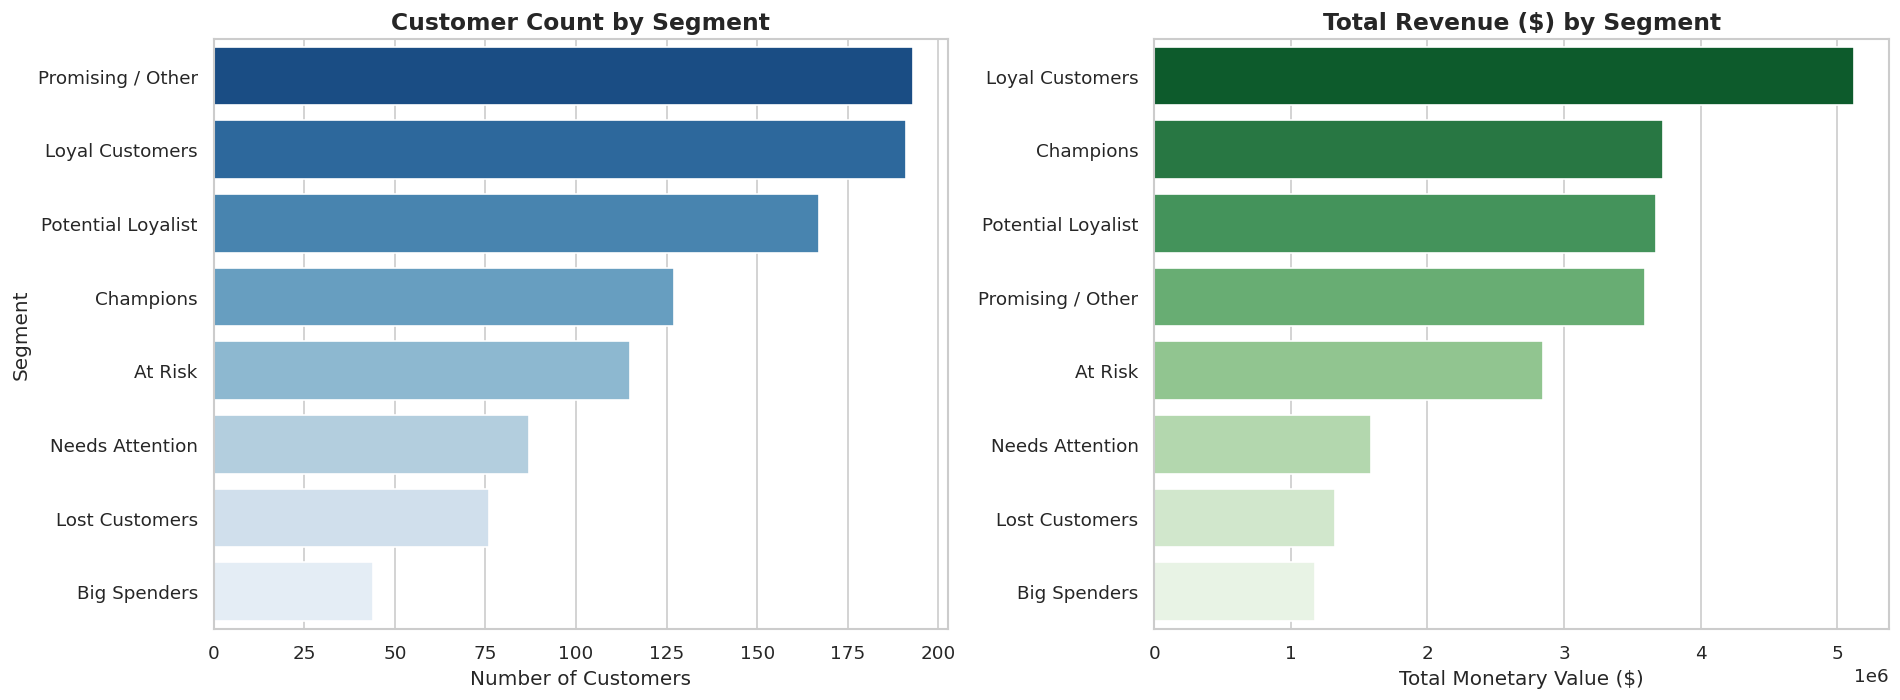

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Customer Count by Segment
sns.barplot(
    data=segment_summary.sort_values(by='Customer_Count', ascending=False),
    x='Customer_Count', y='Segment_Name',
    palette='Blues_r', ax=axes[0], hue='Segment_Name', legend=False
)
axes[0].set_title('Customer Count by Segment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Customers')
axes[0].set_ylabel('Segment')

# 2. Total Revenue Contribution by Segment
sns.barplot(
    data=segment_summary.sort_values(by='Total_Revenue', ascending=False),
    x='Total_Revenue', y='Segment_Name',
    palette='Greens_r', ax=axes[1], hue='Segment_Name', legend=False
)
axes[1].set_title('Total Revenue ($) by Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Monetary Value ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

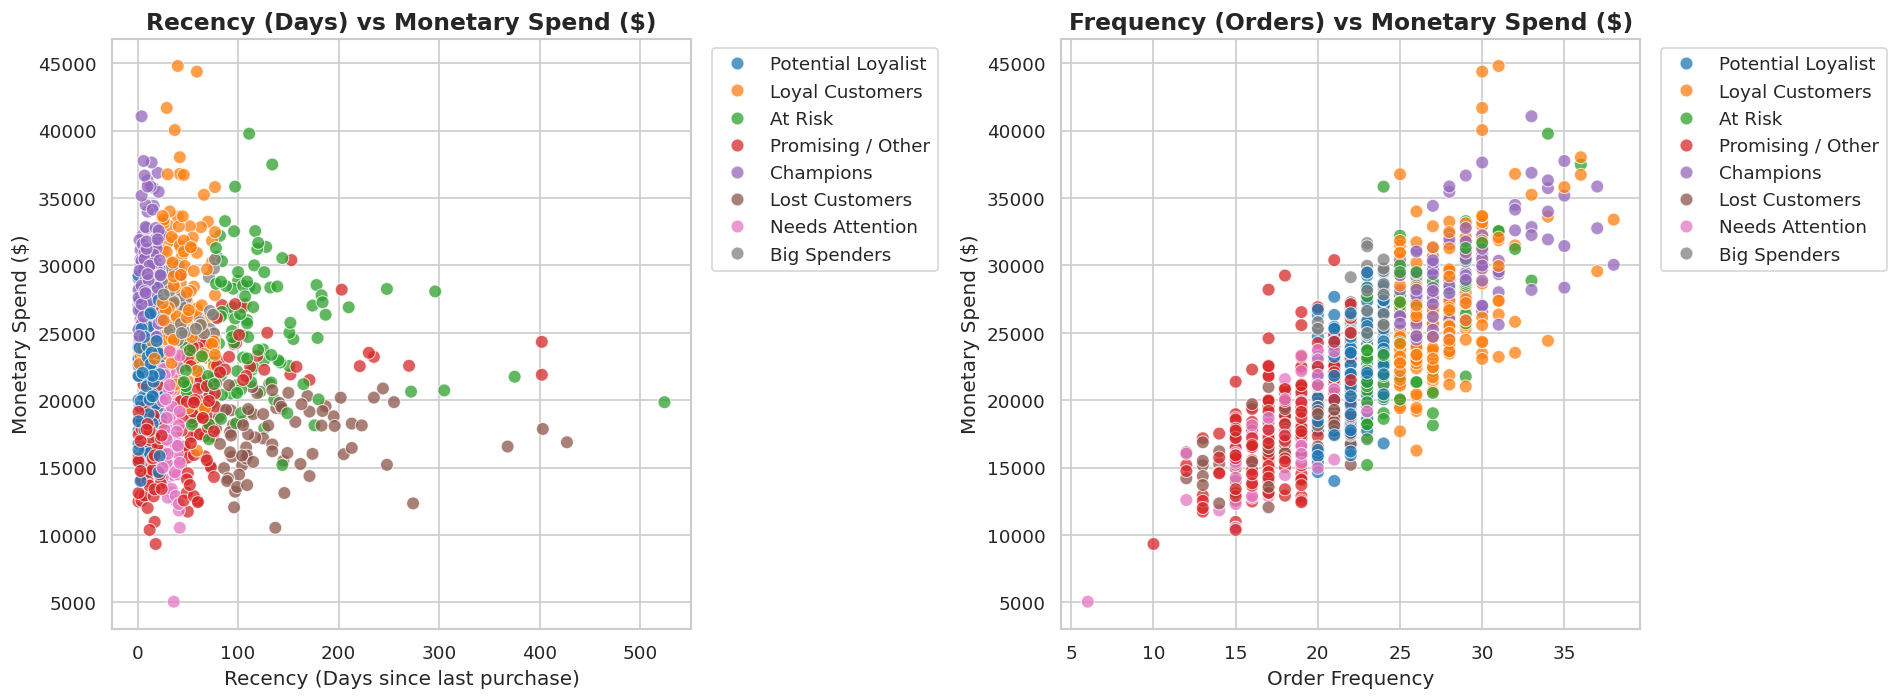

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Recency vs Monetary
sns.scatterplot(
    data=rfm_clean, x='Recency', y='Monetary', hue='Segment_Name',
    palette='tab10', alpha=0.75, s=60, ax=axes[0]
)
axes[0].set_title('Recency (Days) vs Monetary Spend ($)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Recency (Days since last purchase)')
axes[0].set_ylabel('Monetary Spend ($)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# Scatter: Frequency vs Monetary
sns.scatterplot(
    data=rfm_clean, x='Frequency', y='Monetary', hue='Segment_Name',
    palette='tab10', alpha=0.75, s=60, ax=axes[1]
)
axes[1].set_title('Frequency (Orders) vs Monetary Spend ($)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Order Frequency')
axes[1].set_ylabel('Monetary Spend ($)')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

## 9. 🏙️ Demographic & Regional Revenue Analysis
We analyze transaction volume and revenue distribution across geographic locations and demographic variables.

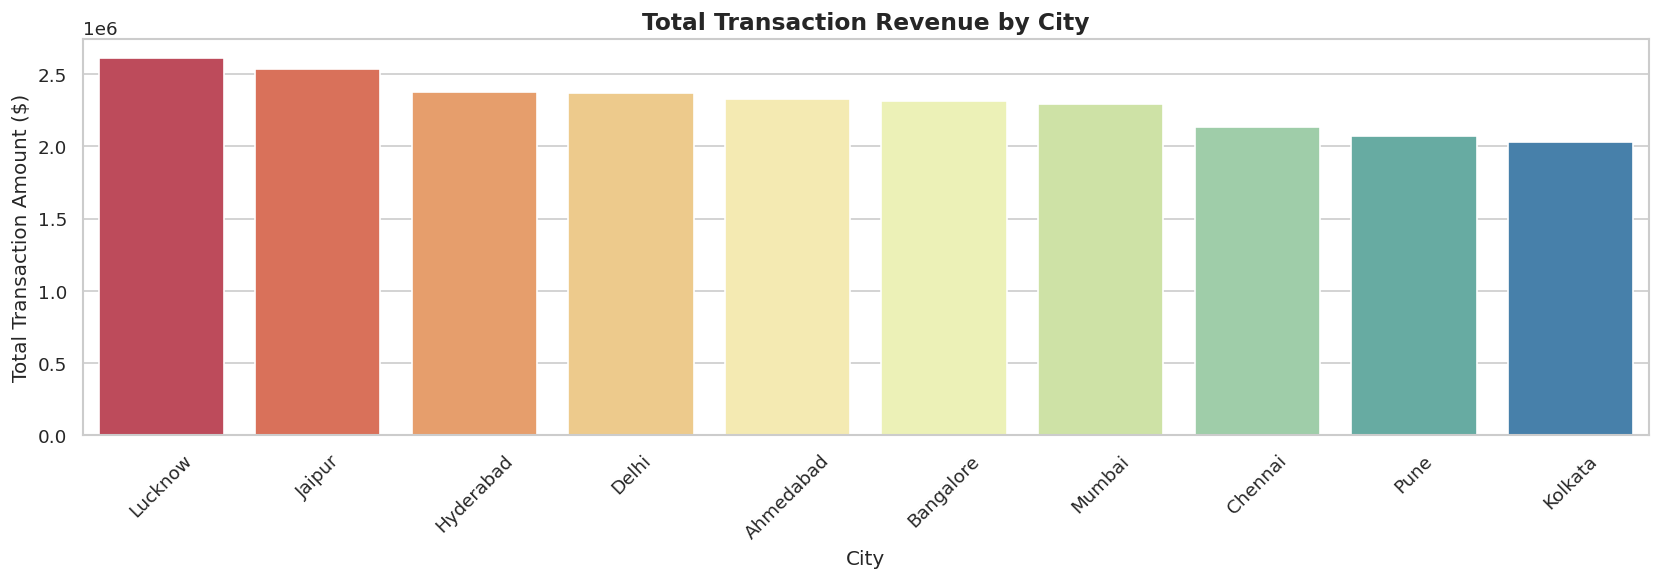

In [11]:
plt.figure(figsize=(14, 5))
city_spend = merged_df.groupby('City')['TransactionAmount'].sum().reset_index().sort_values(by='TransactionAmount', ascending=False)

sns.barplot(
    data=city_spend, x='City', y='TransactionAmount',
    palette='Spectral', hue='City', legend=False
)
plt.title('Total Transaction Revenue by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Transaction Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. 📊 Pareto Analysis (80/20 Revenue Distribution)
The Pareto Principle posits that roughly 80% of consequences come from 20% of causes (e.g. 80% of revenue from top 20% of customers). 

Here, we divide the customer population into 10 expenditure deciles ($D_1$ to $D_{10}$, where $D_1$ represents the top 10% highest spenders) and construct a dual-axis Pareto chart to evaluate revenue concentration.

,Decile,Monetary,Cumulative_Revenue,Cumulative_Share_%
0,D1,3333443.49,3333443.49,14.46
1,D2,2897719.86,6231163.35,27.03
2,D3,2680961.56,8912124.91,38.66
3,D4,2511399.27,11423524.18,49.55
4,D5,2362436.64,13785960.82,59.80
5,D6,2219432.09,16005392.91,69.43
6,D7,2050055.16,18055448.07,78.32
7,D8,1891709.36,19947157.43,86.53
8,D9,1707605.30,21654762.73,93.93
9,D10,1398436.93,23053199.66,100.00


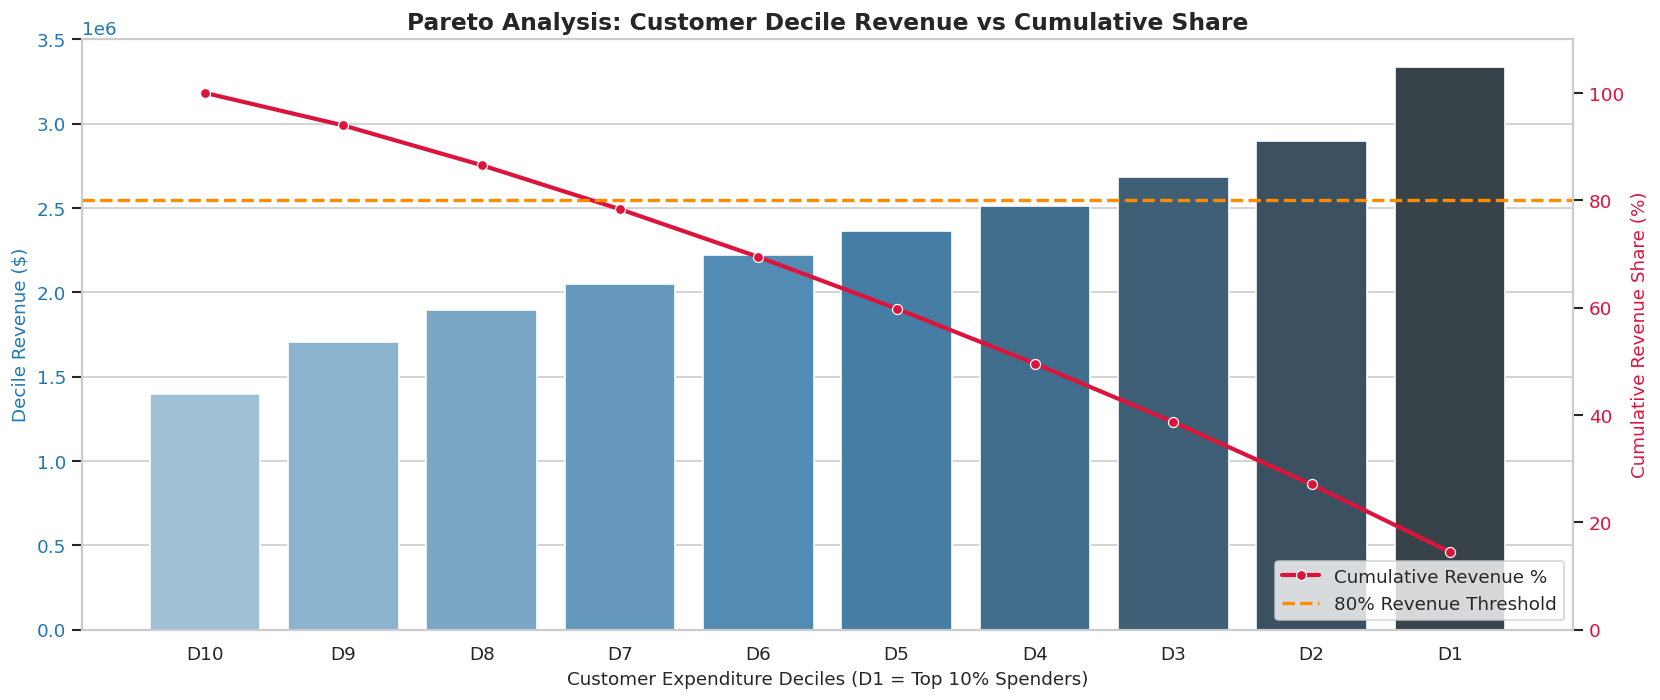

In [12]:
# Sort customers by Monetary spend descending
pareto_data = rfm_clean.sort_values(by='Monetary', ascending=False).reset_index(drop=True)

# Assign deciles (D1 = Top 10% spenders, D10 = Bottom 10% spenders)
pareto_data['Decile'] = pd.qcut(
    pareto_data['Monetary'], q=10, 
    labels=[f'D{i}' for i in range(10, 0, -1)]
)

# Aggregate revenue per decile
pareto_df = pareto_data.groupby('Decile', observed=False)['Monetary'].sum().reset_index()
pareto_df = pareto_df.iloc[::-1].reset_index(drop=True) # Ensure D1 is first

# Calculate cumulative metrics
pareto_df['Cumulative_Revenue'] = pareto_df['Monetary'].cumsum()
pareto_df['Cumulative_Share_%'] = (pareto_df['Cumulative_Revenue'] / pareto_df['Monetary'].sum()) * 100

display(pareto_df)

# Dual-Axis Pareto Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Primary Bar Chart (Decile Revenue)
sns.barplot(
    data=pareto_df, x='Decile', y='Monetary',
    palette='Blues_d', ax=ax1, hue='Decile', legend=False
)
ax1.set_title('Pareto Analysis: Customer Decile Revenue vs Cumulative Share', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Expenditure Deciles (D1 = Top 10% Spenders)', fontsize=11)
ax1.set_ylabel('Decile Revenue ($)', fontsize=11, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Secondary Line Chart (Cumulative Percentage)
ax2 = ax1.twinx()
sns.lineplot(
    data=pareto_df, x='Decile', y='Cumulative_Share_%',
    color='crimson', marker='o', linewidth=2.5, ax=ax2, label='Cumulative Revenue %'
)
ax2.axhline(80, color='darkorange', linestyle='--', linewidth=2, label='80% Revenue Threshold')
ax2.set_ylabel('Cumulative Revenue Share (%)', fontsize=11, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 110)
ax2.grid(False)

# Legend positioning
ax2.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

## 11. 💡 Strategic Marketing Recommendations & Action Plan

Based on the RFM segmentation and empirical revenue distributions, we recommend the following tailored actions:

| Customer Segment | Key Traits | Tailored Strategy & Action Plan |
| :--- | :--- | :--- |
| **🏆 Champions** (12.7% of base, $3.73M revenue) | High recency (avg 10.7 days), high frequency (28.6 orders), high spend ($29.3k) | **VIP Treatment & Advocacy**: Enroll in exclusive VIP rewards, early product launches, referral programs, and dedicated concierge support. |
| **💎 Loyal Customers** (19.1% of base, $5.12M revenue) | Consistent buyers (27.7 orders), strong spend ($26.8k) | **Up-selling & Cross-selling**: Recommend complementary high-margin product bundles; incentivize higher basket sizes with tiered volume discounts. |
| **🌱 Potential Loyalists** (16.7% of base, $3.67M revenue) | Recent purchasers (11.4 days), moderate frequency | **Engagement & Nurturing**: Implement onboarding drip campaigns, point-based loyalty incentives, and personalized product recommendations. |
| **⚠️ At Risk** (11.5% of base, $2.85M revenue) | Past frequent buyers who have not transacted recently (avg 118 days) | **Reactivation Campaigns**: Deliver aggressive limited-time discount vouchers, survey churn drivers, and launch personalized re-engagement emails. |
| **🚪 Lost Customers** (7.6% of base, $1.32M revenue) | Low recency (148 days lapse), lowest frequency and spend | **Cost-Effective Win-back**: Low-cost remarketing via email newsletters and seasonal promotions; avoid expensive paid ad retargeting. |
| **⭐ Big Spenders** (4.4% of base, $1.18M revenue) | High transaction value but moderate frequency | **Frequency Enhancement**: Introduce subscription delivery models, personalized premium service reminders, and replenishment triggers. |

---